### Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:
1. tracking agent behaviour with logging, analytics, and debugging
2. Transforming prompts, tool selection, and output formatting
3. Adding retries, fallbacks and early termination logic.
4. Applying rate limits, guardrails, and PII detection

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

### Summarisation Middleware

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Smmarization is useful for the following:

1. Long-running conversations that exceed context windows.
2. Multi-turn dialouges with extensive history.
3. Applications where preserving full conversation context matters.

In [2]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

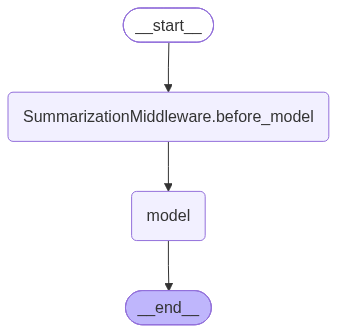

In [3]:
## Messagebased Summarization

agent = create_agent(
    model="gpt-5",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-5",
            trigger=("messages",10),
            keep=("messages",4) 
        )
    ]
)

agent

In [4]:
### Run with thread id
config={"configurable":{"thread_id":"test-1"}}

In [5]:
## Alternative test data
questions = [
    "what is 2+2",
    "what is 10*5",
    "what is 200/4",
    "what is 15-7",
    "what is 15*15",
    "what is 4*4",
    "what is 10-2",
    "what is 1/1",
    "what is 16/4",
    "what is 18/2",
    "what is 10/2"
]

for q in questions:
    response=agent.invoke({"messages": [HumanMessage(content=q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")  

Messages: {'messages': [HumanMessage(content='what is 2+2', additional_kwargs={}, response_metadata={}, id='9aa1b97b-7391-4925-b461-f1ba47f35996'), AIMessage(content='4', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 12, 'total_tokens': 22, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EQS12ohzBPHJufPQckOLMiAiNit2T', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0c2b3-4ea4-7253-8d2f-95694de1e69f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 10, 'total_tokens': 22, 'input_token_det

In [6]:
from langchain_core.tools import tool

@tool
def search_hotels(city:str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, gym, pool,wifi, 350/night,
    2. City Inn - 4 star gym, pool,wifi, 2250/night,
    3. Budget Stay - 3 star gym, pool,wifi, 150/night
    """
    
agent = create_agent(
    model="gpt-5",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-5",
            trigger=("tokens",250),
            keep=("tokens",200)
        )
    ]
)

config={"configurable":{"thread_id":"test-2"}}

In [7]:
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4 # 4 chars ~ 1 token

In [8]:
#Run test

cities = ["paris","london","tokyo","new york","dubai","singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

paris: ~171 tokens, 4 messages
[HumanMessage(content='Find hotels in paris', additional_kwargs={}, response_metadata={}, id='b1d96137-13bc-45cd-930b-fbeaf11f94fc'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 216, 'prompt_tokens': 134, 'total_tokens': 350, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EQS1VdLbGWKp4u4JQvq6NePOMNSfM', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0c2b3-c939-70f1-8369-9f59d30ed11c-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': 'call_mFKEpxVE36Vpi3guxvdVRv76', 

### Human In The Loop MiddleWare

Pause agent execution for human approval, editing or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:

1. High-stakes operations requiring human approval
2. Compliance workflows where human oversight is mandatory.
3. Long-running conversations where human feedback guides the agent.

In [9]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id:str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject {subject}"

In [10]:
agent=create_agent(
    model="gpt-5",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,
            }
        )
    ]
)

In [11]:
config = {"configurable": {"thread_id": "email-approve-test"}}

# step 1: Request

result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [12]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='3527b0f7-5d3f-4a59-88ee-f11364955e79'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 165, 'prompt_tokens': 178, 'total_tokens': 343, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EQS40TWXqYQLAzAy30dassxotafUb', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0c2b6-24d4-7563-b7ee-fe258e544784-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'john@

In [13]:
from langgraph.types import Command

# Step 2: Approve
if "__interrupt__" in result:
    print("Paused!! Approving.....")

    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )

    print(f"Result: {result['messages'][-1].content}")

Paused!! Approving.....
Result: Your email has been sent to john@test.com with the subject "Hello" and body "How are you?".


In [14]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='3527b0f7-5d3f-4a59-88ee-f11364955e79'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 165, 'prompt_tokens': 178, 'total_tokens': 343, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EQS40TWXqYQLAzAy30dassxotafUb', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0c2b6-24d4-7563-b7ee-fe258e544784-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'john@

### Reject

In [15]:
agent=create_agent(
    model="gpt-5",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,
            }
        )
    ]
)

In [16]:
config = {"configurable": {"thread_id": "email-reject-test"}}

# step 1: Request

result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [17]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='9a82716f-3755-4147-8626-0a7d6abfe95f'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 101, 'prompt_tokens': 178, 'total_tokens': 279, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EQS6Ky9RJ5cqwXzUxNka3waIZVXkC', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0c2b8-55e3-7991-9518-bf2ad4b615fa-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'john@t

In [18]:
# Step 2: Reject
if "__interrupt__" in result:
    print("Paused!! Rejecting.....")

    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )

    print(f"Result: {result['messages'][-1].content}")

Paused!! Rejecting.....
Result: I couldn’t send the email due to a tool issue. Here’s what I was going to send:
- To: john@test.com
- Subject: Hello
- Body: How are you?

Would you like me to try sending it now, or make any changes first?
